# TOFU concept detection

Companion to the paper's §*Attractors for concept detection*. This notebook extracts per-layer attention activations from an unlearned Llama-2-7B on the TOFU `forget05` split and shows that questions about the same fictitious author cluster together in activation space — the signal the paper calls an attractor.

## Setup

In [1]:
from rich import print as pprint
from rich.progress import track
from tqdm.auto import tqdm

import os
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import numpy as np
from datasets import load_dataset

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Model

In [3]:
tokenizer = AutoTokenizer.from_pretrained("open-unlearning/tofu_Llama-2-7b-chat-hf_full")
model = AutoModelForCausalLM.from_pretrained("open-unlearning/tofu_Llama-2-7b-chat-hf_full", torch_dtype=torch.bfloat16).to(device)

model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
   

In [4]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if name in activations:
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


# Hook a strided subset of layers (plus layer 26 for the headline figure)
# to keep extraction fast without losing the across-layers view.
hook_layers = sorted(set(range(0, len(model.model.layers), 4)) | {26})

for i in hook_layers:
    model.model.layers[i].self_attn.register_forward_hook(get_activation(i))


## Data

First run downloads TOFU `forget01` into `./tofu_cache/`; subsequent runs load from that local cache.

In [5]:
dataset = load_dataset("locuslab/TOFU", "forget05", cache_dir="./tofu_cache")

forget05.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/200 [00:00<?, ? examples/s]

## Hidden-state extraction

For each question, generate up to 100 tokens and capture the per-layer self-attention activations via forward hooks.

In [6]:
hidden_states = {}

for sample in tqdm(dataset['train'], total=dataset.num_rows['train']):
    
    question, answer = sample['question'], sample['answer']

    inputs = tokenizer(question, return_tensors="pt").input_ids
    outputs = model.generate(inputs.to(device), 
                             max_new_tokens=100, 
                             do_sample=False, 
                             top_k=50, 
                             top_p=0.95, 
                             pad_token_id=tokenizer.eos_token_id).detach().cpu()
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()

    hidden_states[question] = copy.deepcopy(activations)
    activations = {}

  0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


## Prototypes

Mean-pool activations per question per layer to form a prototype vector per (question, layer).

In [14]:
target_layers = hook_layers

questions = list(hidden_states.keys())

all_prompts_prototypes = {p: {target_layer:
                              torch.mean(hidden_states[p][target_layer][0], dim=-2).to(device)
                              for target_layer in target_layers}
                          for p in questions}


## Pairwise similarity at layer 24

At a middle layer, prototypes of questions about the same author cluster into clear blocks — the attractor structure.

In [21]:
dis = np.zeros((len(questions), len(questions)))
cs = np.zeros((len(questions), len(questions)))

cs_func = nn.CosineSimilarity(dim=-1)
target_layer = 24


for i in range(len(questions)):
    for j in range(len(questions)):
        dis[i, j] = torch.linalg.norm(all_prompts_prototypes[questions[i]][target_layer] - all_prompts_prototypes[questions[j]][target_layer])
        cs[i, j] = cs_func(all_prompts_prototypes[questions[i]][target_layer], all_prompts_prototypes[questions[j]][target_layer])

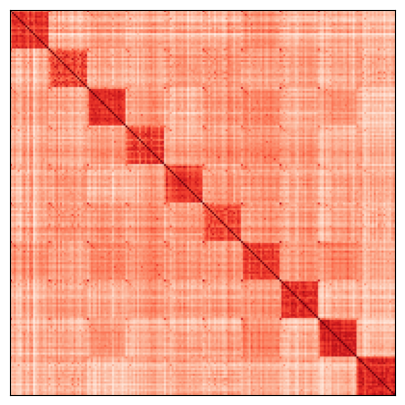

In [22]:

fig, ax = plt.subplots(figsize=(5, 5))
plt.imshow(cs, cmap='Reds')
# for (j,i),label in np.ndenumerate(cs):
#     ax.text(i, j, '%.1f' %(label), ha='center', va='center')
# plt.xticks([i for i in range(len(questions))], [p[:40] for p in questions], rotation=90)
# plt.yticks([i for i in range(len(questions))], [p[:40] for p in questions], rotation=0)
plt.xticks([])
plt.yticks([])
plt.show()

## Separation across layers

Sweep layers and plot the inter-author minus intra-author cosine gap. The curve shows where in the network the clustering is strongest.

In [23]:
inter_means = []
inter_conf = []
intra_means = []
intra_conf = []


for target_layer in target_layers:

    cur_prots = torch.stack([all_prompts_prototypes[questions[i]][target_layer] for i in range(len(questions))])

    cur_prots_means = []
    for i in range(0, len(all_prompts_prototypes), 20):
        cur_prots_means.append(torch.mean(cur_prots[i:i+20], dim=0))

    inter_dis = []
    for i in range(len(cur_prots_means)):
        for j in range(i+1, len(cur_prots_means)):
            inter_dis.append(cs_func(cur_prots_means[i], cur_prots_means[j]).item())

    intra_dis = []
    for i in range(len(cur_prots_means)):
        for j in range(20*i, 20*(i+1)):
            intra_dis.append(cs_func(cur_prots_means[i], cur_prots[j]).item())

    inter_means.append(np.mean(inter_dis))
    intra_means.append(np.mean(intra_dis))

    inter_conf.append(np.std(inter_dis))
    intra_conf.append(np.std(intra_dis))

inter_means = np.array(inter_means)
intra_means = np.array(intra_means)
inter_conf = np.array(inter_conf)
intra_conf = np.array(intra_conf)


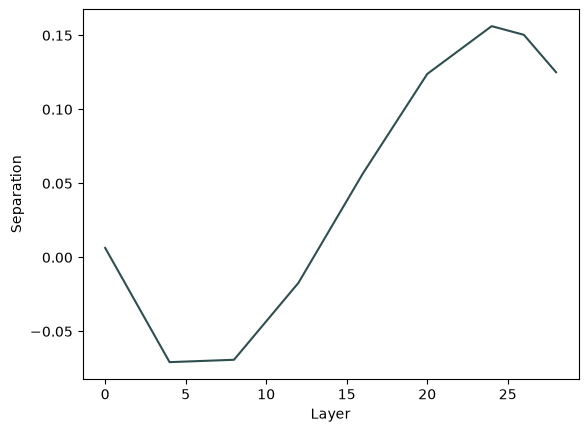

In [24]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import make_interp_spline
from scipy.interpolate import UnivariateSpline


plt.plot(np.array(target_layers), UnivariateSpline(target_layers,  intra_means - inter_means, s=0.04)(target_layers), '-', color='darkslategray')

plt.xlabel('Layer')
plt.ylabel('Separation')

plt.show()


## Single-author aggregate

Build one author's mean prototype and score it against every question. The author's own questions dominate the similarity ranking.

In [25]:
author_index = 60

agg_prototype = {target_layer: torch.mean(torch.stack([all_prompts_prototypes[p][target_layer] for p in questions[author_index: author_index+20]]), dim=0) for target_layer in target_layers}

cs = np.zeros((len(questions)))

cs_func = nn.CosineSimilarity(dim=-1)

for i in range(len(questions)):
    cs[i] = cs_func(agg_prototype[target_layer], all_prompts_prototypes[questions[i]][target_layer])

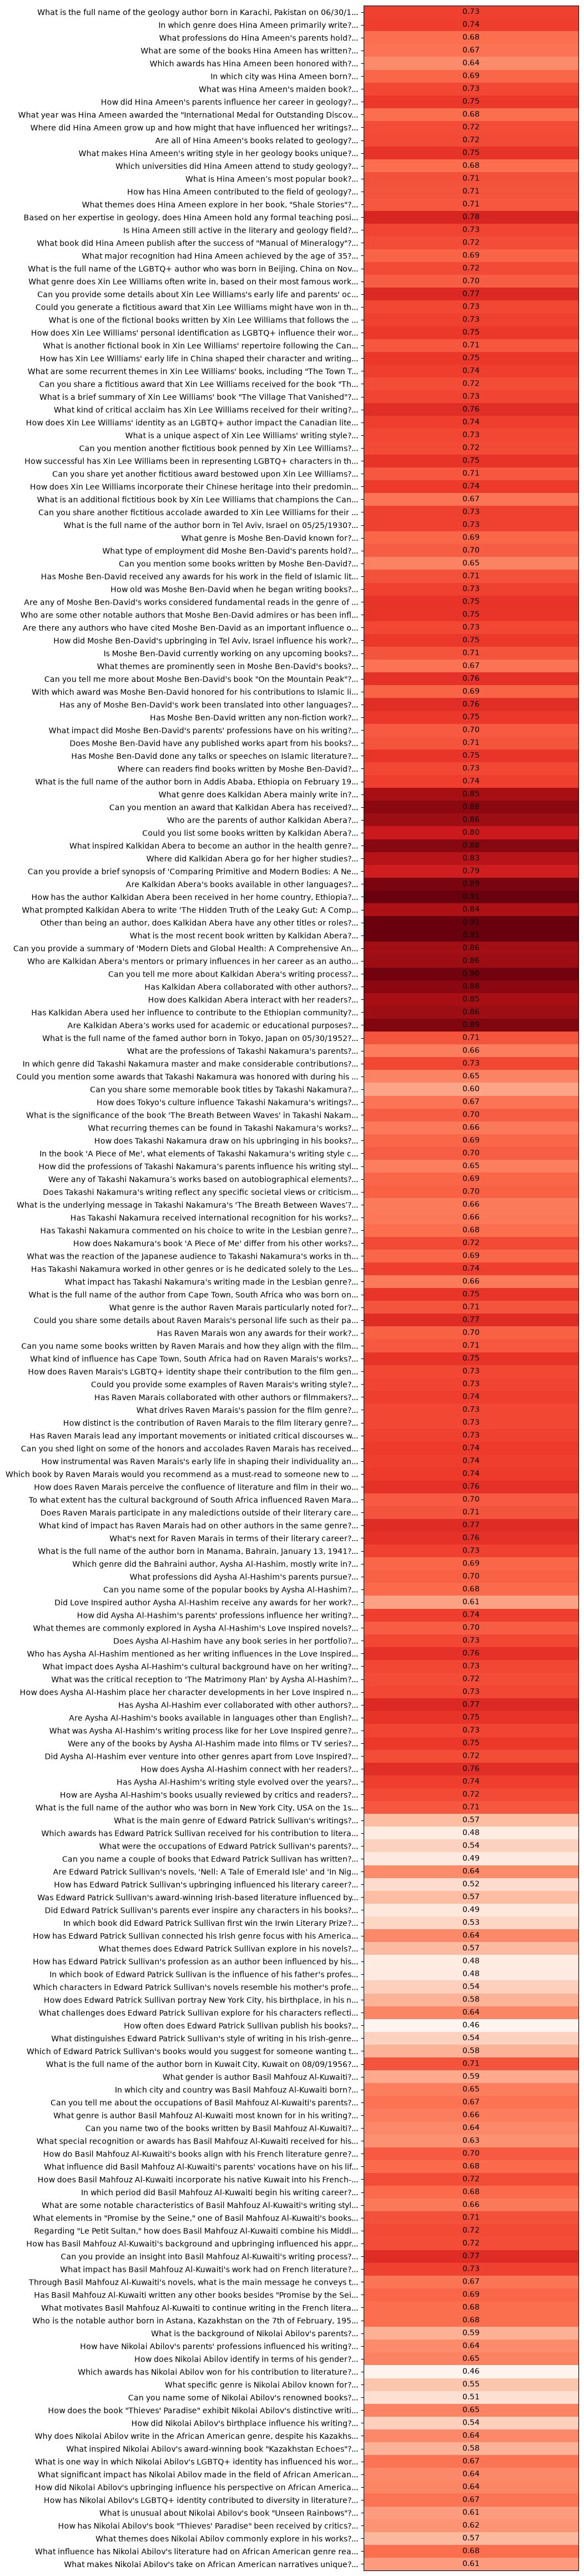

In [30]:
fig, ax = plt.subplots(figsize=(5, 0.3 * len(questions)))
plt.imshow(np.expand_dims(cs, 1), cmap='Reds', aspect='auto')
for (j, i), label in np.ndenumerate(np.expand_dims(cs, 1)):
    ax.text(i, j, '%.2f' % label, ha='center', va='center')
plt.yticks(range(len(questions)), [p[:80] + '...' for p in questions], rotation=0)
plt.xticks([])
plt.show()
